## Task 1

In [29]:
import pandas as pd 
import numpy as np 

cars_df = pd.read_csv('cars.csv')

In [30]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


Horsepower is an object but should be numeric.  
Origin is int, but should be categorical.

## Task 2 Clean the Data

In [31]:
cars_df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [32]:
X= cars_df.loc[:, 'cylinders':'origin']
y= cars_df['mpg']

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

In [34]:
X_train['horsepower'] = pd.to_numeric(X_train['horsepower'], errors='coerce')
X_test['horsepower'] = pd.to_numeric(X_test['horsepower'], errors='coerce')

In [35]:
hp_med = X_train['horsepower'].median()
X_train['horsepower']= X_train['horsepower'].fillna(hp_med)
X_test['horsepower']= X_test['horsepower'].fillna(hp_med)

## Task 3 Decide What Goes In and What Stays Out

We split prior to cleaning the horsepower column above.  
We cannot use car name because they are individual string values and would not serve well as categorical or numeric columns  

## Task 4 When Should you split?

We split our data prior to cleaning the horsepower column to avoid data leakage when filling with the median value. If we had used the entire data set median, this would provide information about the data in the test set.  
The same concept would apply to scaling.  


## Task 5 Encode the Categorical Column

In [36]:
categorical_cols = ['origin', 'model year', 'cylinders']
numeric_cols = ['displacement']


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ohe= OneHotEncoder(sparse_output=False, drop='first') # This satisfies question 6
origin_array= ohe.fit_transform(X_train[['origin']])
# get column names from sklearn
origin_cols= ohe.get_feature_names_out(['origin'])
# build df from array
df_origin = pd.DataFrame(origin_array, columns=origin_cols, dtype=int)
df1=pd.concat([X_train.drop(columns=['origin']).reset_index(), df_origin], axis=1)
print(df1.to_string())



     index  cylinders  displacement  horsepower  weight  acceleration  model year  origin_2  origin_3
0        3          8         304.0       150.0    3433          12.0          70         0         0
1       18          4          97.0        88.0    2130          14.5          70         0         1
2      376          4          91.0        68.0    2025          18.2          82         0         1
3      248          4          91.0        60.0    1800          16.4          78         0         1
4      177          4         115.0        95.0    2694          15.0          75         1         0
5       63          8         400.0       175.0    4385          12.0          72         0         0
6      246          4          78.0        52.0    1985          19.4          78         0         1
7      352          4          98.0        65.0    2380          20.7          81         0         0
8      108          4          97.0        88.0    2279          19.0          73 

In [38]:
# The following blocks split...for learning!
ohe= OneHotEncoder(sparse_output=False, drop='first')
origin_array= ohe.fit_transform(X_test[['origin']])
# get column names from sklearn
origin_array


array([[0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.

In [39]:
origin_cols= ohe.get_feature_names_out(['origin'])
# build df from array
origin_cols


array(['origin_2', 'origin_3'], dtype=object)

In [40]:
df_origin = pd.DataFrame(origin_array, columns=origin_cols, dtype=int)
df_origin


,origin_2,origin_3
0,0,1
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
75,0,0
76,0,0
77,0,0
78,1,0


In [41]:
X_test.drop(columns=['origin']).reset_index()

,index,cylinders,displacement,horsepower,weight,acceleration,model year
0,198,4,91.0,53.0,1795,17.4,76
1,396,4,120.0,79.0,2625,18.6,82
2,33,6,232.0,100.0,2634,13.0,71
3,208,8,318.0,150.0,3940,13.2,76
4,93,8,318.0,150.0,4237,14.5,73
...,...,...,...,...,...,...,...
75,249,8,260.0,110.0,3365,15.5,78
76,225,6,250.0,110.0,3520,16.4,77
77,367,4,112.0,88.0,2605,19.6,82
78,175,4,90.0,70.0,1937,14.0,75


In [42]:
df=pd.concat([X_test.drop(columns=['origin']).reset_index(), df_origin], axis=1)
print(df)

    index  cylinders  displacement  horsepower  weight  acceleration  \
0     198          4          91.0        53.0    1795          17.4   
1     396          4         120.0        79.0    2625          18.6   
2      33          6         232.0       100.0    2634          13.0   
3     208          8         318.0       150.0    3940          13.2   
4      93          8         318.0       150.0    4237          14.5   
..    ...        ...           ...         ...     ...           ...   
75    249          8         260.0       110.0    3365          15.5   
76    225          6         250.0       110.0    3520          16.4   
77    367          4         112.0        88.0    2605          19.6   
78    175          4          90.0        70.0    1937          14.0   
79    285          8         305.0       130.0    3840          15.4   

    model year  origin_2  origin_3  
0           76         0         1  
1           82         0         0  
2           71         0

In the above code, we added drop='first' to drop origin 1 to avoid multicollinearity. It does not matter because the third answer is always implied by the other two responses.  

## Task 7

In [43]:
from sklearn.preprocessing import StandardScaler


In [44]:
## training
ss = StandardScaler()
df1_std = df1.copy()
df1_std[numeric_cols] = ss.fit_transform(df1[numeric_cols])

print(df1_std)




     index  cylinders  displacement  horsepower  weight  acceleration  \
0        3          8      1.090196       150.0    3433          12.0   
1       18          4     -0.922996        88.0    2130          14.5   
2      376          4     -0.981350        68.0    2025          18.2   
3      248          4     -0.981350        60.0    1800          16.4   
4      177          4     -0.747936        95.0    2694          15.0   
..     ...        ...           ...         ...     ...           ...   
313     71          3     -1.185587        97.0    2330          13.5   
314    106          8      1.537573       180.0    4499          12.5   
315    270          4     -0.563150        95.0    2515          14.8   
316    348          4     -1.000801        62.0    2050          17.3   
317    102          4     -0.922996        46.0    1950          21.0   

     model year  origin_2  origin_3  
0            70         0         0  
1            70         0         1  
2        

In [45]:
df_std = df.copy()
df_std[numeric_cols] = ss.fit_transform(df[numeric_cols])
print(df_std)

    index  cylinders  displacement  horsepower  weight  acceleration  \
0     198          4     -0.995119        53.0    1795          17.4   
1     396          4     -0.729081        79.0    2625          18.6   
2      33          6      0.298375       100.0    2634          13.0   
3     208          8      1.087314       150.0    3940          13.2   
4      93          8      1.087314       150.0    4237          14.5   
..    ...        ...           ...         ...     ...           ...   
75    249          8      0.555239       110.0    3365          15.5   
76    225          6      0.463502       110.0    3520          16.4   
77    367          4     -0.802471        88.0    2605          19.6   
78    175          4     -1.004292        70.0    1937          14.0   
79    285          8      0.968056       130.0    3840          15.4   

    model year  origin_2  origin_3  
0           76         0         1  
1           82         0         0  
2           71         0

In [46]:
print(df1.mean())
print(df1['displacement'].std())


index            201.295597
cylinders          5.430818
displacement     191.904088
horsepower       103.106918
weight          2969.015723
acceleration      15.639937
model year        76.103774
origin_2           0.176101
origin_3           0.207547
dtype: float64
102.98380205067406


# Task 8

In [47]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X= cars_df.loc[:, 'cylinders':'origin']
y= cars_df['mpg']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Define columns
categorical_cols = ['origin', 'model year', 'cylinders']
numeric_cols = ['displacement']

# Build Column Transformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('category', OneHotEncoder(sparse_output=False), categorical_cols)
])

# Build pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])

# Fit model
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2:  {r2:.4f}')
print(f'MAE: {mae:.4f}')

R2:  0.8134
MAE: 2.5484


# Advanced Task 1

Text(0.5, 1.0, 'Residuals')

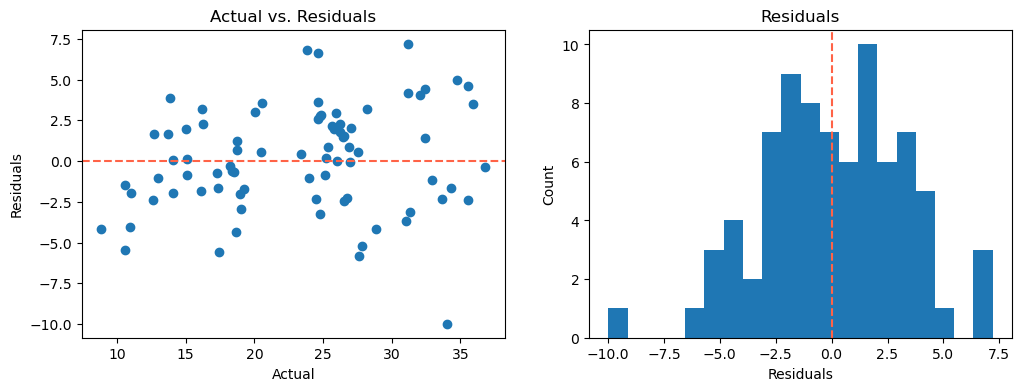

In [57]:
import matplotlib.pyplot as plt

residuals = y_pred - y_test

residuals

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals)
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.title('Actual vs. Residuals')


plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20)
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Residuals')

1. Errors are pretty evenly spread
2. There are a few that are very far off
3. Our model could use some work and maybe needs more data to become more accurate.

# Advanced Task 2

In [ ]:
cars_df['horsepower'] 

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [61]:
cars_df['horsepower'] = pd.to_numeric(cars_df['horsepower'], errors='coerce')
cars_df['horsepower']= cars_df['horsepower'].fillna(hp_med)


X= cars_df.loc[:, 'cylinders':'model year']
y= cars_df['mpg']



# Create model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
print(f'R2:  {r2:.4f}')
print(f'MAE: {mae:.4f}')

R2:  0.8087
MAE: 2.6311


1. The preprocessed model performed better, but the non-preprocessed was surprisingly close
2. Skipping encoding means we couldn't use the columns where it was necessary because they weren't numeric values. Without encoding, models can't process categorical data. Skipping scaling adjusts the range of features so that no single feature can dominate due to magnitude.
3. If the data is already clean and completely numeric, preprocessing isn't necessary.